In [1]:
import sys
print(sys.executable)

/Users/dipasmitadebroy/Documents/Artificial_Intelligence/ml_projects/house-price-prediction/venv/bin/python


In [2]:
# pandas  → tabular data manipulation
# numpy   → numerical operations
# matplotlib / seaborn → visualizations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots appear inside the notebook (not in a separate window)
%matplotlib inline

# Set a clean visual theme for all charts
sns.set_theme(style="whitegrid", palette="muted")

print("Libraries loaded")

Libraries loaded


In [3]:
# pd.read_csv() reads a CSV file and loads it into a DataFrame
# A DataFrame is like a table — rows and columns, each column has a name

df = pd.read_csv("../data/housing.csv")

# .head() shows the first 5 rows — a quick sanity check the file loaded correctly
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
#understand the shape of the data
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

#find datatypes, non-null values, memory usage
df.info()

Rows: 20640, Columns: 10
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
#summary statistics of the data
df.describe().round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


In [8]:
# Finding missing value columns

# .isnull() returns a DataFrame of the same shape as df, but with True for missing values and False for non-missing values
missing_values = df.isnull().sum()

# Filter columns with missing values
missing_values = missing_values[missing_values > 0]
print("Columns with missing values:")
print(missing_values)

#show missing value columns as a percentage of total rows
missing_percentage = (missing_values / df.shape[0]) * 100
print("\nPercentage of missing values:")
print(missing_percentage.round(2).astype(str) + '%')

Columns with missing values:
total_bedrooms    207
dtype: int64

Percentage of missing values:
total_bedrooms    1.0%
dtype: str


In [10]:
# replace missing values with the median of the column

# .fillna() replaces NaN (missing) values with the value you pass in
# inplace=True modifies the original DataFrame instead of making a copy

# NEW — correct way in pandas 2.0+
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

#confirm missing values are filled
print("\nMissing values after filling:")
print(df["total_bedrooms"].isnull().sum())




Missing values after filling:
0


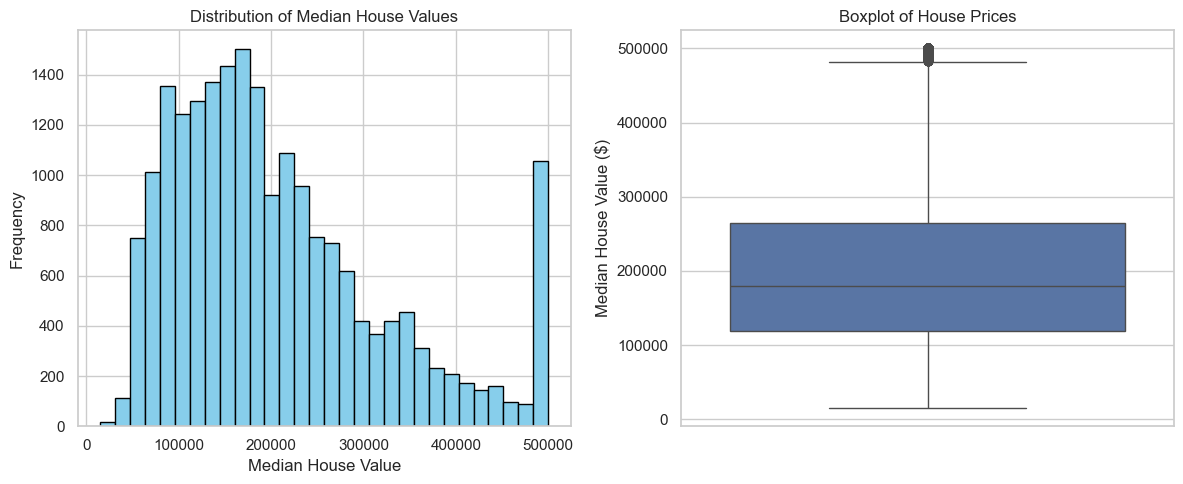

In [14]:
# create a figure with 2 side by side charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left chart: frequency of price ranges
axes[0].hist(df["median_house_value"], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title("Distribution of Median House Values")
axes[0].set_xlabel("Median House Value")
axes[0].set_ylabel("Frequency")

# RIGHT: Boxplot — shows median, quartiles, and outliers
sns.boxplot(y=df["median_house_value"], ax=axes[1], color="#4C72B0")
axes[1].set_title("Boxplot of House Prices")
axes[1].set_ylabel("Median House Value ($)")
plt.tight_layout()
plt.savefig("../outputs/01_target_distribution.png", dpi=150)
plt.show()

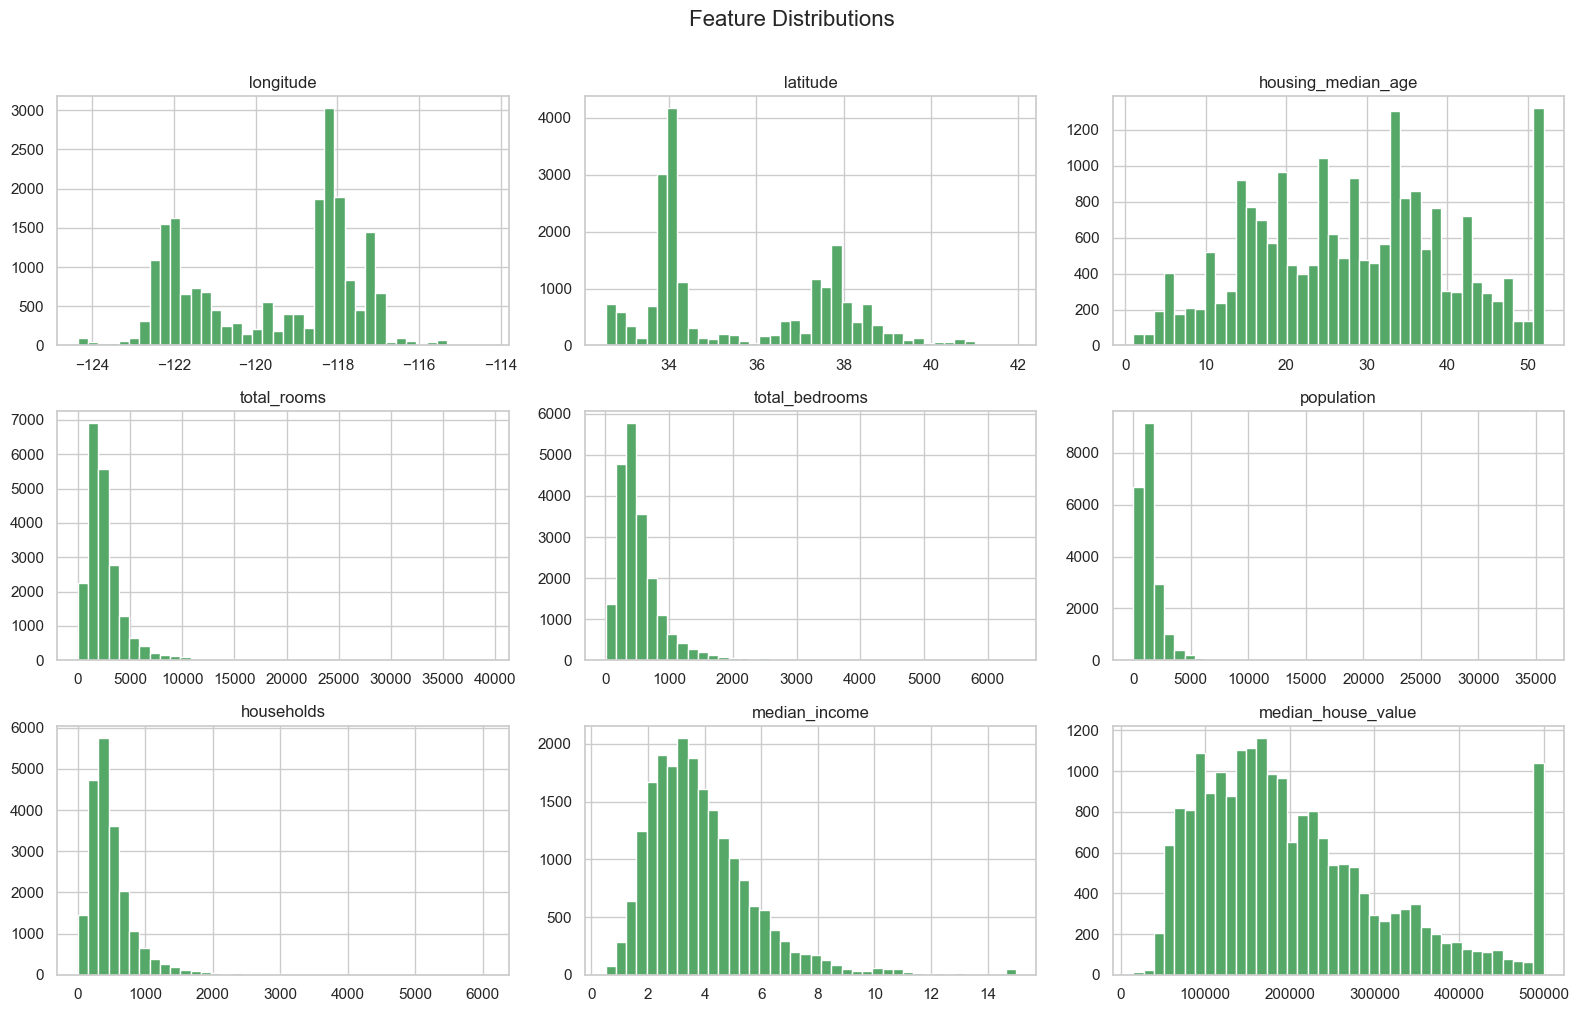

In [18]:
# .select_dtypes(include=[np.number]) gets only numeric columns
# This excludes 'ocean_proximity' which is a text column

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# .hist() plots a histogram for every column in the list
df[numeric_cols].hist(figsize=(16, 10), bins=40, color="#55A868", edgecolor="white")

plt.suptitle("Feature Distributions", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/02_feature_distributions.png", dpi=150)
plt.show()

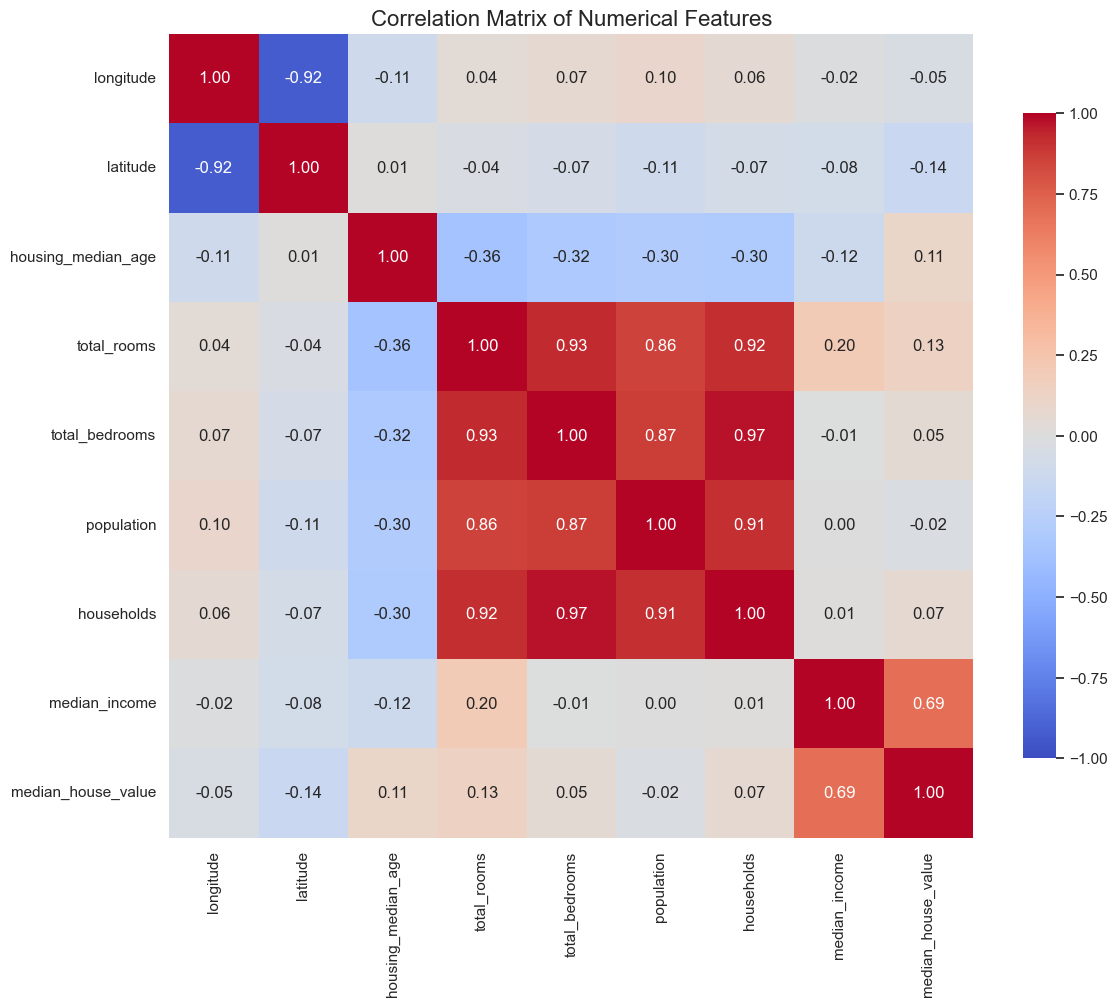

In [19]:
# .corr() calculates the correlation matrix for the DataFrame
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8}, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/03_correlation_matrix.png", dpi=150)
plt.show()

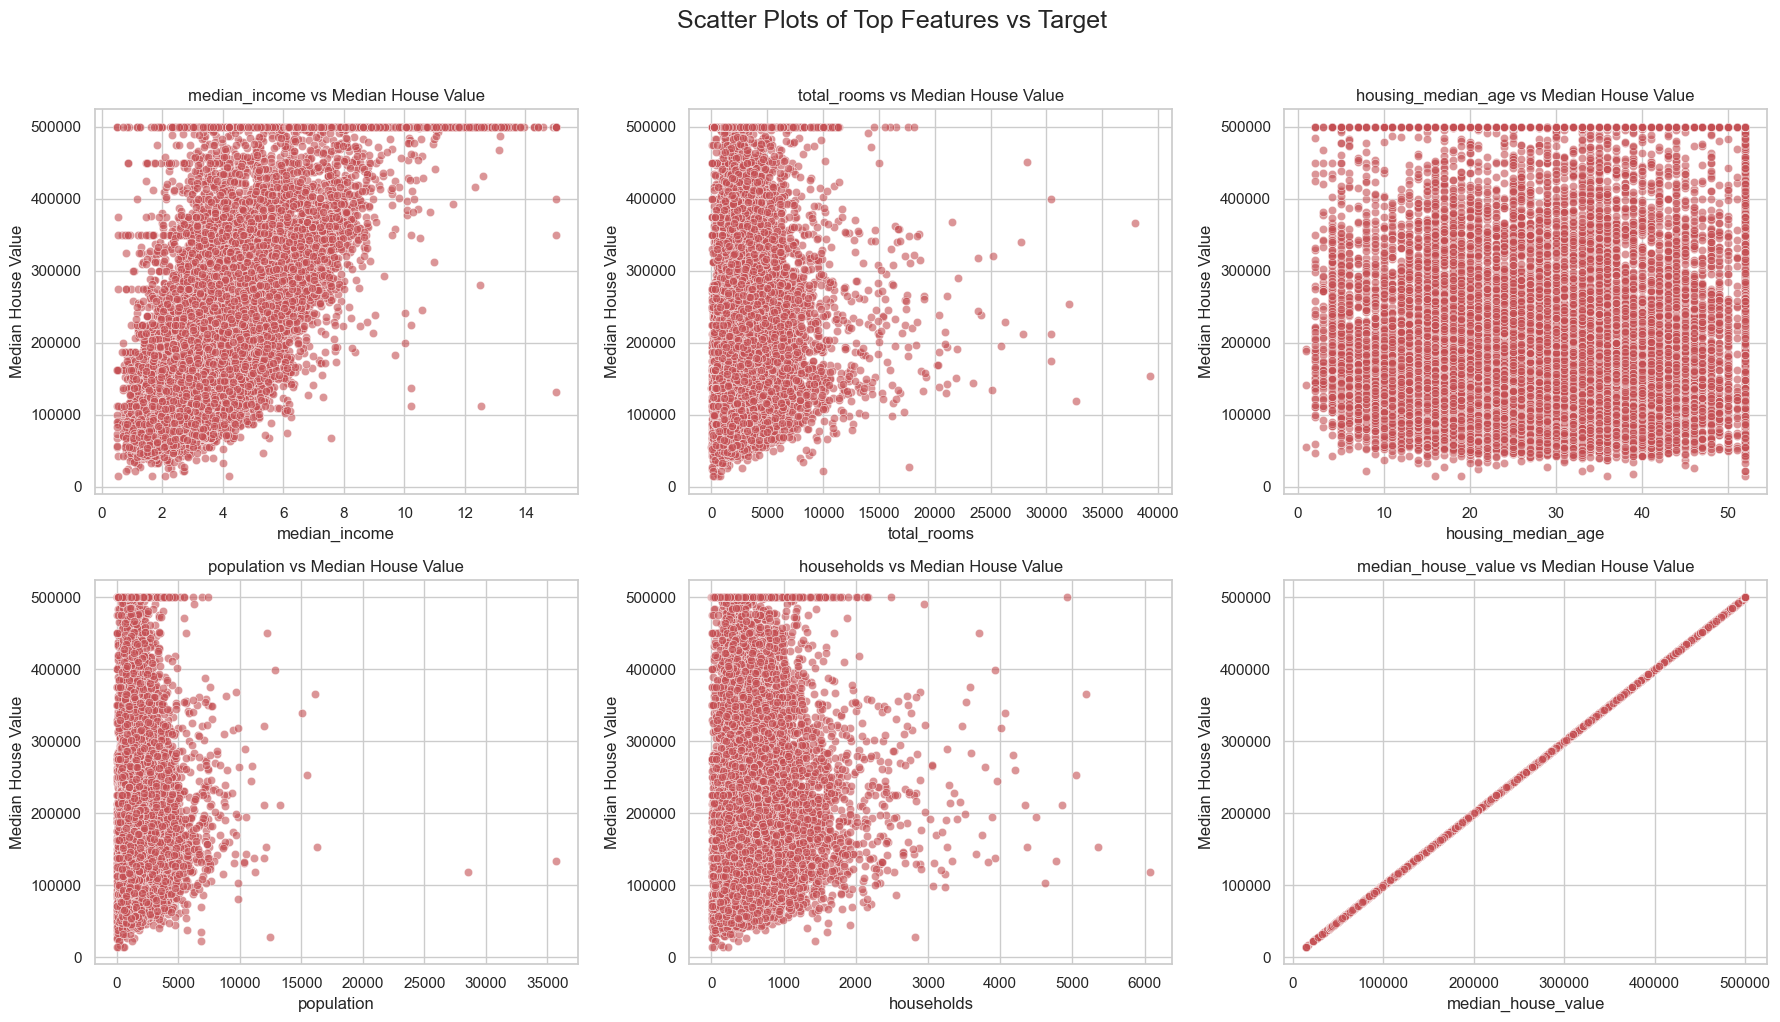

In [20]:
top_features = ["median_income", "total_rooms", "housing_median_age", "population", "households", "median_house_value"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # flatten the 2D array of axes to 1D for easy iteration

for i, feature in enumerate(top_features):
    sns.scatterplot(x=df[feature], y=df["median_house_value"], ax=axes[i], color="#C44E52", alpha=0.6)
    axes[i].set_title(f"{feature} vs Median House Value")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Median House Value")

plt.suptitle("Scatter Plots of Top Features vs Target", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/04_scatter_plots.png", dpi=150)
plt.show()

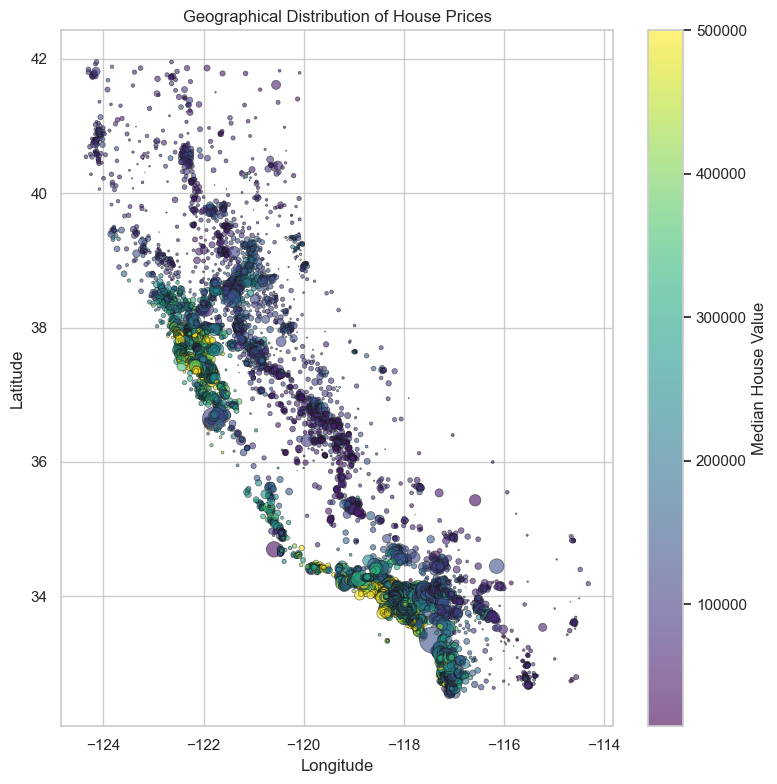

In [22]:
# geographical visualization of house prices

plt.figure(figsize=(8, 8))

scatter = plt.scatter(df["longitude"], df["latitude"], c=df["median_house_value"], cmap="viridis", alpha=0.6, s=df["population"]/100, edgecolor="k", linewidth=0.5)
plt.colorbar(scatter, label="Median House Value")
plt.title("Geographical Distribution of House Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig("../outputs/05_geographical_distribution.png", dpi=150)
plt.show()

Ocean Proximity Counts:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Average House Price by Ocean Proximity:
  ocean_proximity  median_house_value
0          ISLAND       380440.000000
1        NEAR BAY       259212.311790
2      NEAR OCEAN       249433.977427
3       <1H OCEAN       240084.285464
4          INLAND       124805.392001


/var/folders/c3/fpdk_vfx1t567y6sl3bn2vj40000gn/T/ipykernel_67905/3275293959.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="ocean_proximity", y="median_house_value", data=ocean_avg_price, palette="Blues_d")


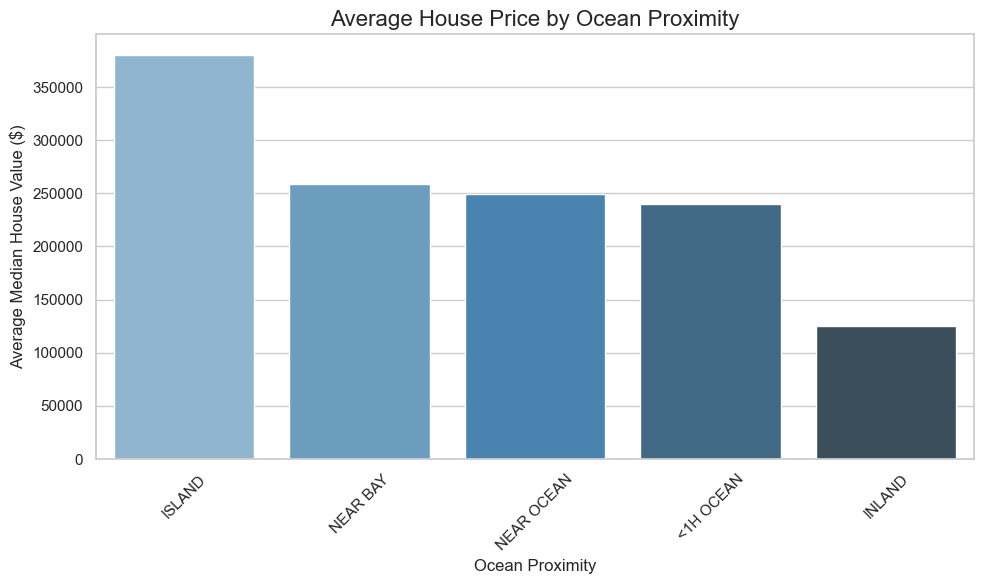

In [23]:
#Ocean proximity analysis

# 'ocean_proximity' is a text column with 5 categories:
# NEAR BAY, <1H OCEAN, INLAND, NEAR OCEAN, ISLAND

# .value_counts() counts the frequency of each category in the 'ocean_proximity' column
proximity_counts = df["ocean_proximity"].value_counts()
print("Ocean Proximity Counts:")
print(proximity_counts)

# groupby 'ocean_proximity' and calculate mean house price for each category

ocean_avg_price = df.groupby("ocean_proximity")["median_house_value"].mean().sort_values(ascending=False).reset_index()
print("\nAverage House Price by Ocean Proximity:")
print(ocean_avg_price)  

plt.figure(figsize=(10, 6))
sns.barplot(x="ocean_proximity", y="median_house_value", data=ocean_avg_price, palette="Blues_d")
plt.title("Average House Price by Ocean Proximity", fontsize=16)
plt.xlabel("Ocean Proximity")   
plt.ylabel("Average Median House Value ($)")    
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/06_ocean_proximity.png", dpi=150)
plt.show()

In [24]:
# Rooms per household — average living space per home
# More meaningful than raw total_rooms
df["rooms_per_household"] = df["total_rooms"] / df["households"]

# Bedrooms as a fraction of total rooms — lower = more living space vs sleeping space
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

# People per household — proxy for average household/family size
df["population_per_household"] = df["population"] / df["households"]

print("New features created:")
print("  - rooms_per_household")
print("  - bedrooms_per_room")
print("  - population_per_household")

# Check: do the new features correlate better with house price?
new_features = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]
new_corr = df[new_features + ["median_house_value"]].corr()["median_house_value"].drop("median_house_value")
print(f"\nNew feature correlations with house price:")
print(new_corr.round(3))

New features created:
  - rooms_per_household
  - bedrooms_per_room
  - population_per_household

New feature correlations with house price:
rooms_per_household         0.152
bedrooms_per_room          -0.233
population_per_household   -0.024
Name: median_house_value, dtype: float64


In [25]:
# Save the processed DataFrame so Notebook 02 starts from this clean state
# This separates EDA (analysis) from modelling (building) — good practice

df.to_csv("../data/housing_clean.csv", index=False)

print(f"Saved to data/housing_clean.csv")
print(f"Final shape: {df.shape[0]} rows × {df.shape[1]} columns")

Saved to data/housing_clean.csv
Final shape: 20640 rows × 13 columns


In [26]:
print("""
EDA SUMMARY
===========
1. Dataset: 20,640 rows × 10 original columns
2. Missing data: total_bedrooms (~1%) — fixed with median fill
3. Target: median_house_value — right-skewed, capped at $500,001
4. Strongest predictor: median_income (correlation +0.69)
5. Geography matters: coastal blocks are significantly more expensive
6. Engineered 3 new features: rooms_per_household, bedrooms_per_room, population_per_household
7. ocean_proximity needs encoding before modelling (it's text)

Next: Notebook 02 — Test Linear Regression Assumptions, then train the model
""")


EDA SUMMARY
1. Dataset: 20,640 rows × 10 original columns
2. Missing data: total_bedrooms (~1%) — fixed with median fill
3. Target: median_house_value — right-skewed, capped at $500,001
4. Strongest predictor: median_income (correlation +0.69)
5. Geography matters: coastal blocks are significantly more expensive
6. Engineered 3 new features: rooms_per_household, bedrooms_per_room, population_per_household
7. ocean_proximity needs encoding before modelling (it's text)

Next: Notebook 02 — Test Linear Regression Assumptions, then train the model

